# Проект. Исследование стартапов

## Введение

Поле для вашего введения: опишите контекст и цели проекта. Чтобы изменить содержимое ячейки, дважды нажмите на неё или нажмите «Ввод».


**Цель**: провести исследовательский анализ закономерностей финансирования стартапов и оценить перспективы выхода на рынок с покупкой и развитием компаний.

**Задачи:**
1. Загрузить данные и познакомиться с их содержимым:
- Вывод общей информации
2. Провести предобработку данных.
3. Провести Инжиниринг признаков:
- Группы по срокам финансирования
- Выделение средних и нишевых сегментов рынка
4. Работа с выбросами и анализ:
- Анализируем и помечаем выбросы в каждом из сегментов
- Определяем границы рассматриваемого периода, отбрасываем аномалии
- Анализ типов финансирования по объёму и популярности
5. Анализ динамики:
- Динамика предоставления финансирования по годам
- Динамика размера общего финансирования по массовым сегментам рынка для растущих в 2014 году сегментов
- Годовая динамика доли возвращённых средств по типам финансирования
6. Сформулировать итоговый вывод и рекомендации.

## Шаг 1. Знакомство с данными: загрузка и предобработка

Датасет получен из базы данных стартапов.

Название основного датасета — `cb_investments.zip`. Внутри архива один файл — `cb_investments.csv`.

Описание данных:
* `name` — название компании.
* `homepage_url` — ссылка на сайт компании.
* `category_list` — категории, в которых работает компания. Указываются через `|`.
* `market` — основной рынок или отрасль компании.
* `funding_total_usd` — общий объём привлечённых инвестиций в долларах США.
* `status` — текущий статус компании, например `operating`, `closed` и так далее.
* `country_code` — код страны, например USA.
* `state_code` — код штата или региона, например, CA.
* `region` — регион, например, SF Bay Area.
* `city` — город, в котором расположена компания.
* `funding_rounds` — общее число раундов финансирования.
* `participants` — число участников в раундах финансирования.
* `founded_at` — дата основания компании.
* `founded_month` — месяц основания в формате `YYYY-MM`.
* `founded_quarter` — квартал основания в формате `YYYY-QN`.
* `founded_year` — год основания.
* `first_funding_at` — дата первого финансирования.
* `mid_funding_at` — дата среднего по времени раунда финансирования.
* `last_funding_at` — дата последнего финансирования.
* `seed` — сумма инвестиций на посевной стадии.
* `venture` — сумма венчурных инвестиций.
* `equity_crowdfunding` — сумма, привлечённая через долевой краудфандинг.
* `undisclosed` — сумма финансирования нераскрытого типа.
* `convertible_note` — сумма инвестиций через конвертируемые займы.
* `debt_financing` — сумма долгового финансирования.
* `angel` — сумма инвестиций от бизнес-ангелов.
* `grant` — сумма полученных грантов.
* `private_equity` — сумма инвестиций в виде прямых (частных) вложений.
* `post_ipo_equity` — сумма финансирования после IPO.
* `post_ipo_debt` — сумма долгового финансирования после IPO.
* `secondary_market` — сумма сделок на вторичном рынке.
* `product_crowdfunding` — сумма, привлечённая через продуктовый краудфандинг.
* `round_A` — `round_H` — сумма инвестиций в соответствующем раунде.

Название дополнительного датасета — `cb_returns.csv`. Он содержит суммы возвратов по типам финансирования в миллионах долларов по годам.

Описание данных:
* `year` — год возврата средств.
* `seed` — сумма возвратов от посевных инвестиций.
* `venture` — сумма возвратов от венчурных инвестиций.
* `equity_crowdfunding` — сумма, возвращённая по долевому краудфандингу.
* `undisclosed` — сумма возвратов нераскрытого типа.
* `convertible_note` — сумма возвратов через конвертируемые займы.
* `debt_financing` — сумма возвратов от долгового финансирования.
* `angel` — сумма возвратов бизнес-ангелам.
* `grant` — сумма возвратов по грантам.
* `private_equity` — сумма возвратов прямых (частных) вложений.
* `post_ipo_equity` — сумма возвратов от IPO.
* `post_ipo_debt` — сумма возвратов от долгового IPO.
* `secondary_market` — сумма возвратов от сделок на вторичном рынке.
* `product_crowdfunding` — сумма возвратов по продуктовому краудфандингу.

Файлы находятся в папке `datasets`, если вы выполняете работу на платформе. В случае, если вы делаете работу локально, доступ к файлам в папке можно получить по адресу `https://code.s3.yandex.net/datasets/` + имя файла.

### 1.1. Вывод общей информации

Загрузите необходимые для работы библиотеки.

Совет: если вы неоднократно используете какой-либо код, вынесите его в начало проекта в виде функций.

In [1]:
# Импортируем библиотеки
import pandas as pd
import numpy as np

# Загружаем библиотеки для визуализации данных
import matplotlib.pyplot as plt
import seaborn as sns

# Установка 
!pip install missingno

# Импорт
import missingno as msno

In [2]:
# Загружаем датасеты cb_investments и cb_returns
df = pd.read_csv("https://code.s3.yandex.net/datasets/cb_investments.zip", sep=';', low_memory=False)

# Для cb_returns указываем столбец для чтения в качестве индекса при загрузке
cb = cb_returns = pd.read_csv("https://code.s3.yandex.net/datasets/cb_returns.csv", index_col='year') 

Выведите информацию, которая необходима для принятия решений о предобработке.

In [3]:
# Выводим информацию о датафрейме
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54294 entries, 0 to 54293
Data columns (total 40 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   name                  49437 non-null  object 
 1   homepage_url          45989 non-null  object 
 2   category_list         45477 non-null  object 
 3    market               45477 non-null  object 
 4    funding_total_usd    49438 non-null  object 
 5   status                48124 non-null  object 
 6   country_code          44165 non-null  object 
 7   state_code            30161 non-null  object 
 8   region                44165 non-null  object 
 9   city                  43322 non-null  object 
 10  funding_rounds        49438 non-null  float64
 11  participants          30473 non-null  float64
 12  founded_at            38554 non-null  object 
 13  founded_month         38482 non-null  object 
 14  founded_quarter       38482 non-null  object 
 15  founded_year       

In [4]:
# Выводим информацию о таблице cb_returns
cb.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 15 entries, 2000 to 2014
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   seed                  15 non-null     float64
 1   venture               15 non-null     float64
 2   equity_crowdfunding   15 non-null     float64
 3   undisclosed           15 non-null     float64
 4   convertible_note      15 non-null     float64
 5   debt_financing        15 non-null     float64
 6   angel                 15 non-null     float64
 7   grant                 15 non-null     float64
 8   private_equity        15 non-null     float64
 9   post_ipo_equity       15 non-null     float64
 10  post_ipo_debt         15 non-null     float64
 11  secondary_market      15 non-null     float64
 12  product_crowdfunding  15 non-null     float64
dtypes: float64(13)
memory usage: 1.6 KB


In [5]:
# Выведем столбцы с большим количеством пропусков
df.isna().sum().sort_values(ascending = False)

state_code              24133
mid_funding_at          24006
participants            23821
founded_month           15812
founded_quarter         15812
founded_at              15740
founded_year            15740
city                    10972
country_code            10129
region                  10129
category_list            8817
 market                  8817
homepage_url             8305
status                   6170
name                     4857
private_equity           4856
round_E                  4856
round_F                  4856
round_D                  4856
round_C                  4856
round_G                  4856
round_B                  4856
round_A                  4856
product_crowdfunding     4856
secondary_market         4856
post_ipo_debt            4856
post_ipo_equity          4856
venture                  4856
grant                    4856
angel                    4856
debt_financing           4856
convertible_note         4856
undisclosed              4856
equity_cro

In [6]:
# Столбцы с пропусками в относительных значениях
df.isna().sum().sort_values(ascending = False) / df.shape[0]

state_code              0.444487
mid_funding_at          0.442148
participants            0.438741
founded_month           0.291229
founded_quarter         0.291229
founded_at              0.289903
founded_year            0.289903
city                    0.202085
country_code            0.186558
region                  0.186558
category_list           0.162394
 market                 0.162394
homepage_url            0.152963
status                  0.113641
name                    0.089457
private_equity          0.089439
round_E                 0.089439
round_F                 0.089439
round_D                 0.089439
round_C                 0.089439
round_G                 0.089439
round_B                 0.089439
round_A                 0.089439
product_crowdfunding    0.089439
secondary_market        0.089439
post_ipo_debt           0.089439
post_ipo_equity         0.089439
venture                 0.089439
grant                   0.089439
angel                   0.089439
debt_finan

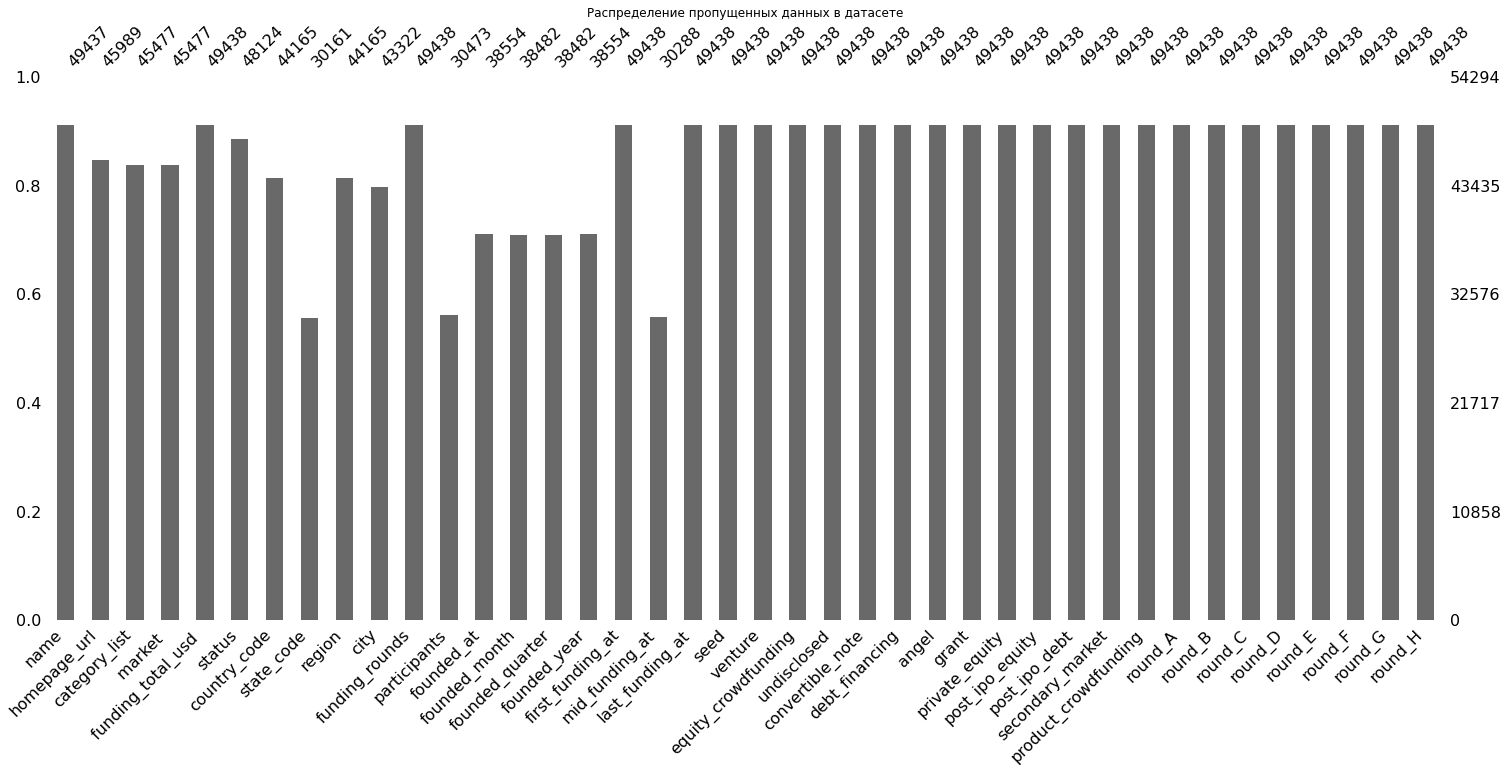

In [7]:
# Добавим визуализацию пропусков по столбцам 
msno.bar(df)
plt.title('Распределение пропущенных данных в датасете')
plt.show()

In [8]:
# Выводим разброс значений датафрейма
df.describe()

,funding_rounds,participants,founded_year,seed,venture,equity_crowdfunding,undisclosed,convertible_note,debt_financing,angel,...,secondary_market,product_crowdfunding,round_A,round_B,round_C,round_D,round_E,round_F,round_G,round_H
count,49438.000000,30473.000000,38554.000000,4.943800e+04,4.943800e+04,4.943800e+04,4.943800e+04,4.943800e+04,4.943800e+04,4.943800e+04,...,4.943800e+04,4.943800e+04,4.943800e+04,4.943800e+04,4.943800e+04,4.943800e+04,4.943800e+04,4.943800e+04,4.943800e+04,4.943800e+04
mean,1.696205,1.451646,2007.094231,2.173215e+05,7.501051e+06,6.163322e+03,1.302213e+05,2.336410e+04,1.888157e+06,6.541898e+04,...,3.845592e+04,7.074227e+03,1.243955e+06,1.492891e+06,1.205356e+06,7.375261e+05,3.424682e+05,1.697692e+05,5.767067e+04,1.423197e+04
std,1.294213,2.022233,9.862177,1.056985e+06,2.847112e+07,1.999048e+05,2.981404e+06,1.432046e+06,1.382046e+08,6.582908e+05,...,3.864461e+06,4.282166e+05,5.531974e+06,7.472704e+06,7.993592e+06,9.815218e+06,5.406915e+06,6.277905e+06,5.252312e+06,2.716865e+06
min,1.000000,0.000000,1636.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.000000,0.000000,2005.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,1.000000,1.000000,2010.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
75%,2.000000,2.000000,2012.000000,2.500000e+04,5.000000e+06,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
max,18.000000,36.000000,2014.000000,1.300000e+08,2.351000e+09,2.500000e+07,2.924328e+08,3.000000e+08,3.007950e+10,6.359026e+07,...,6.806116e+08,7.200000e+07,3.190000e+08,5.420000e+08,4.900000e+08,1.200000e+09,4.000000e+08,1.060000e+09,1.000000e+09,6.000000e+08


In [9]:
# выводим первые строки датафрейма с настройкой отображения всех столбцов
pd.set_option('display.max_columns', None)
df.head()

,name,homepage_url,category_list,market,funding_total_usd,status,country_code,state_code,region,city,funding_rounds,participants,founded_at,founded_month,founded_quarter,founded_year,first_funding_at,mid_funding_at,last_funding_at,seed,venture,equity_crowdfunding,undisclosed,convertible_note,debt_financing,angel,grant,private_equity,post_ipo_equity,post_ipo_debt,secondary_market,product_crowdfunding,round_A,round_B,round_C,round_D,round_E,round_F,round_G,round_H
0,Harvard University,http://harvard.edu,|Education|,Education,"9,00,00,000",operating,USA,MA,Boston,Cambridge,1.0,NaN,1636-09-08,NaN,NaN,1636.0,2014-01-06,NaN,2014-01-06,0.0,0.0,0.0,0.0,0.0,0.0,0.0,90000000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,University of New Brunswick,http://www.unb.ca,NaN,NaN,"20,00,000",operating,NaN,NaN,NaN,NaN,1.0,NaN,1785-01-01,NaN,NaN,1785.0,2014-05-15,NaN,2014-05-15,0.0,2000000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,DuPont,http://www.dupont.com,|Business Services|Agriculture|Automotive|Inve...,Business Services,"90,00,000",operating,USA,DE,"Wilmington, Delaware",Wilmington,1.0,1.0,1802-07-19,NaN,NaN,1802.0,2009-07-02,2009-07-02,2009-07-02,0.0,9000000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,University of Michigan,http://www.umich.edu/,|Education|,Education,"77,00,000",operating,USA,MI,Detroit,Ann Arbor,3.0,0.0,1817-01-01,NaN,NaN,1817.0,2013-11-21,2013-11-21,2014-11-03,0.0,0.0,0.0,1600000.0,0.0,0.0,0.0,6100000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,Case Western Reserve University,http://www.case.edu,|Education|,Education,"5,40,000",operating,USA,OH,Cleveland,Cleveland,1.0,NaN,1826-01-01,NaN,NaN,1826.0,2014-01-14,NaN,2014-01-14,0.0,0.0,0.0,0.0,0.0,0.0,0.0,540000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [10]:
# Выведем строки таблицы cb_returns
cb.head()

,seed,venture,equity_crowdfunding,undisclosed,convertible_note,debt_financing,angel,grant,private_equity,post_ipo_equity,post_ipo_debt,secondary_market,product_crowdfunding
year,,,,,,,,,,,,,
2000,16.70,55.40,0.0,78.21,0.00,8.66,6.43,0.0,0.00,0.94,0.0,0.20,0.0
2001,2.88,23.49,0.0,21.50,0.01,4.49,1.18,0.0,0.00,0.46,0.0,0.46,0.0
2002,6.59,209.42,0.0,25.77,0.02,3.42,3.41,0.0,1.51,0.34,0.0,0.06,0.0
2003,7.74,233.86,0.0,9.40,0.01,1.09,3.41,0.0,1.62,2.11,0.0,0.08,0.0
2004,9.93,555.90,0.0,33.19,0.01,13.55,9.18,0.0,2.19,3.38,0.0,0.55,0.0


Сделайте вывод о полученных данных: каков их объём, соответствуют ли данные описанию, есть ли пропущенные значения, используются ли верные типы данных. Отметьте другие особенности данных, которые вы обнаружите на этой стадии и на которые стоит обратить внимание при предобработке.

**Промежуточный вывод:**

1. Датасет cb_investments (df)

- Объём данных: 54 294 строки, 40 столбцов
- Пропущенные значения: Значительные пропуски в столбцах: state_code (44%), mid_funding_at (44%), participants (44%), founded_month/founded_quarter (29%). Меньше пропусков в инвестиционных столбцах (round_A–round_H, seed, venture и др.) — около 9%.
- Неверные типы данных: funding_total_usd — тип object, должен быть числовым (запятые в числах, например 9,00,00,000), founded_at, first_funding_at, last_funding_at, mid_funding_at — тип object, должны быть datetime.
- Верные типы: Инвестиционные столбцы (float64), funding_rounds (float64).
- Другие особенности: В столбце category_list категории перечислены через |, требуется разделение. В funding_total_usd запятые как разделители разрядов.

2. Датасет cb_returns (cb)

- Объём данных: 15 строк, 14 столбцов
- Пропущенные значения: Отсутствуют (все столбцы имеют 15 ненулевых значений).
- Типы данных: Все типы корректны: year — int64, остальные — float64.

3. План предобработки:

- Для df: Преобразовать funding_total_usd в числовой тип (удалить запятые). Преобразовать даты в datetime. Обработать пропуски (заполнить или удалить строки). Разбить category_list на отдельные категории. Привести названия столбцов к единому стилю.
- Для cb: Предобработка данных не требуется 

### 1.2. Предобработка данных

Проверьте названия столбцов в датасетах: все ли они точно отражают содержимое данных и оформлены в удобном для работы стиле. При необходимости приведите их к единому аккуратному стилю.

In [11]:
# Сохраним размер датасета для дальнейшего сравнения после выполненных изменений
temp = len(df)
print(temp)

54294


In [12]:
# Преобразуем столбцы в snake_case (нижний регистр), удалим лишние пробелы
df.columns = df.columns.str.lower().str.strip()
print(df.columns)

Index(['name', 'homepage_url', 'category_list', 'market', 'funding_total_usd',
       'status', 'country_code', 'state_code', 'region', 'city',
       'funding_rounds', 'participants', 'founded_at', 'founded_month',
       'founded_quarter', 'founded_year', 'first_funding_at', 'mid_funding_at',
       'last_funding_at', 'seed', 'venture', 'equity_crowdfunding',
       'undisclosed', 'convertible_note', 'debt_financing', 'angel', 'grant',
       'private_equity', 'post_ipo_equity', 'post_ipo_debt',
       'secondary_market', 'product_crowdfunding', 'round_a', 'round_b',
       'round_c', 'round_d', 'round_e', 'round_f', 'round_g', 'round_h'],
      dtype='object')


In [13]:
# Выведем названия столбцов датафрейма
df.columns

Index(['name', 'homepage_url', 'category_list', 'market', 'funding_total_usd',
       'status', 'country_code', 'state_code', 'region', 'city',
       'funding_rounds', 'participants', 'founded_at', 'founded_month',
       'founded_quarter', 'founded_year', 'first_funding_at', 'mid_funding_at',
       'last_funding_at', 'seed', 'venture', 'equity_crowdfunding',
       'undisclosed', 'convertible_note', 'debt_financing', 'angel', 'grant',
       'private_equity', 'post_ipo_equity', 'post_ipo_debt',
       'secondary_market', 'product_crowdfunding', 'round_a', 'round_b',
       'round_c', 'round_d', 'round_e', 'round_f', 'round_g', 'round_h'],
      dtype='object')

Уберите в столбце `funding_total_usd` выделение разрядов и приведите его к числовому типу.

In [14]:
# Удалим запятые в столбце funding_total_usd и приведем к числовому типу данных
df['funding_total_usd'] = df['funding_total_usd'].str.replace(',', '')
df['funding_total_usd'] = pd.to_numeric(df['funding_total_usd'], errors = 'coerce')

Обработайте типы данных в столбцах, которые хранят значения даты и времени, если это необходимо.

In [15]:
# Создаём список столбцов
date_list = ['founded_at', 'first_funding_at', 'mid_funding_at', 'last_funding_at']

# Проходим по каждому столбцу и преобразуем в datetime
for column in date_list:
    df[column] = pd.to_datetime(df[column], errors = 'coerce')

В датасете `cb_returns` сделайте столбец `year` индексом всего датасета, если не делали это при загрузке.

# Сделаем столбец year  индексом всего датасета cb
cb = cb.set_index('year')

Обработайте текстовые данные, если это необходимо. Пропуски в текстовых столбцах заполните заглушками там, где это понадобится.

In [16]:
# Ко всем текстовым столбцам с пропусками в данных применяем заглушку unknown
text_columns = ['name', 'homepage_url', 'category_list', 'market', 'status', 'country_code',
                'state_code', 'region', 'city', 'founded_month', 'founded_quarter']
df[text_columns] = df[text_columns].fillna('unknown')

Обработайте полные дубликаты в данных и пропуски в `funding_total_usd`. избавьтесь от тех строк, которые не несут какой-либо информации либо не содержат данных о финансировании.

**Удаляем полные дубликаты по датафрейму:**

In [17]:
# Найдем полные дубликаты пов сему датафрейму
df.duplicated().sum()

4855

In [18]:
# Удалим полные дубликаты по датафрейму
df = df.drop_duplicates()

In [19]:
# Проверим актуальный датафрейм на факт полных дубликатов
df.duplicated().sum()

0

**Удаляем пропуски в столбце funding_total_usd:**

In [20]:
df = df.dropna(subset = ['funding_total_usd'])

Заполните пропуски в значениях `mid_funding_at` на основании значений в столбцах `first_funding_at` и `last_funding_at`. В качестве нового значения вместо пропусков возьмите приблизительно середину интервала между этими двумя датами.

Оцените размер оставшихся пропусков в столбце.

In [21]:
# Считаем количество пропусков в столбце mid_funding_at
df['mid_funding_at'].isna().sum()

13676

In [22]:
mid_dates = df['first_funding_at'] + ((df['last_funding_at'] - df['first_funding_at']) / 2)
df['mid_funding_at'] = df['mid_funding_at'].fillna(mid_dates)

In [23]:
# Посчитаем количество строк на этапе обработки
print(f'Количество строк до обработки: {temp}')
print(f'Количество строк после обработки: {len(df)}')
print(f'Всего удалено строк: {temp - len(df)}')
print(f'Процент отброшенных данных: {round((temp - len(df)) / temp * 100)}')

Количество строк до обработки: 54294
Количество строк после обработки: 40907
Всего удалено строк: 13387
Процент отброшенных данных: 25



Оцените полноту данных и сделайте предварительный вывод о том, достаточно ли данных для решения задач проекта. Какой процент данных был отброшен?


1. Изменение количества строк: 

- Исходно: 54 294 строки
- Удалено: 13389 строк
- После удаления дубликатов и строк с пропусками в funding_total_usd: 40 905 строк

2. Процент отброшенных данных:

- Отброшено 25 % данных - в основном за счёт дубликатов и отсутствия информации о финансировании)

3. Полнота данных:

- Ключевой столбец funding_total_usd не содержит пропусков
- Текстовые столбцы заполнены заглушкой 'unknown'

4. Предварительный вывод:

- Данных обработаны для решения задач
- Основные столбцы, необходимые для анализа (funding_total_usd, даты финансирования, market, статусы), содержат полную информацию
- Дополнительный датасет cb_returns не содержит пропусков и полностью готов к использованию

In [24]:
df['market'] = df['market'].str.strip()
df['market'] = df['market'].str.lower()

## Шаг 2. Инжиниринг признаков

При выполнении заданий не забывайте интерпретировать полученные результаты и делать промежуточные выводы.

### 2.1. Группы по срокам финансирования

Разделите все компании на три группы:

* Единичное финансирование — был всего один раунд финансирования.

* Срок финансирования до года — между первым и последним раундом финансирования прошло не более года.

* Срок финансирования более года.

Визуализируйте соотношение этих групп, создав два графика:

* По количеству компаний: Покажите, какой процент от общего числа компаний относится к каждой из трёх групп.
* По объёму инвестиций: Отобразите, какую долю от общего объёма привлечённых средств получила каждая группа.

Совет: Для ясности и согласованности используйте единую цветовую палитру для всех графиков, чтобы каждая категория (например, «Единичное финансирование») всегда отображалась одним цветом.

In [25]:
# Разделим все компании на три группы финансирования
df['funding_group'] = 'unknown'


funding_group_first = (df['funding_rounds'] == 1)

# Группа 2: funding_rounds > 1 И обе даты есть И разница <= 365 дней
funding_group_second = (df['funding_rounds'] > 1) & (df['first_funding_at'].notna()) & (df['last_funding_at'].notna()) & ((df['last_funding_at'] - df['first_funding_at']).dt.days <= 365)

# Группа 3: funding_rounds > 1 И обе даты есть И разница > 365 дней
funding_group_third = (df['funding_rounds'] > 1) & (df['first_funding_at'].notna()) & (df['last_funding_at'].notna()) & ((df['last_funding_at'] - df['first_funding_at']).dt.days > 365)

df.loc[funding_group_first, 'funding_group'] = 'first'
df.loc[funding_group_second, 'funding_group'] = 'second'
df.loc[funding_group_third, 'funding_group'] = 'third'

print(df['funding_group'].value_counts())

first      24113
third      12291
second      4501
unknown        2
Name: funding_group, dtype: int64


In [26]:
# Посмотрим относительные доли от общего количества
print(df['funding_group'].value_counts(normalize=True) * 100)

first      58.945902
third      30.046202
second     11.003007
unknown     0.004889
Name: funding_group, dtype: float64


In [27]:
# Посмотрим какую долю от общего объёма привлечённых средств получила каждая группа
df.groupby('funding_group')['funding_total_usd'].sum()

funding_group
first      1.993044e+11
second     4.888598e+10
third      4.027090e+11
unknown    3.430000e+07
Name: funding_total_usd, dtype: float64

In [28]:
# Удаляем строки, где funding_group == 'unknown'
df = df[df['funding_group'] != 'unknown']

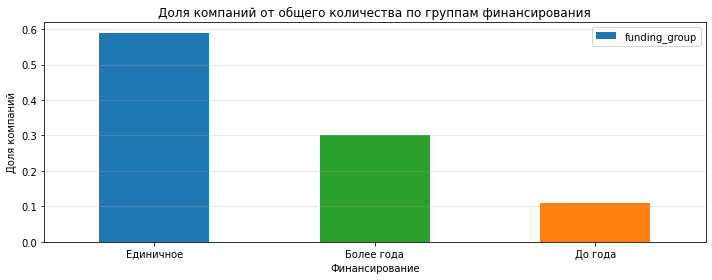

In [29]:
# Сначала переименуй значения в самом датафрейме
df['funding_group'] = df['funding_group'].map({
    'first': 'Единичное',
    'second': 'До года', 
    'third': 'Более года'
})

# Теперь можно строить график
colors = {'Единичное': '#1f77b4',   # синий
          'До года': '#ff7f0e',    # оранжевый
          'Более года': '#2ca02c'} # зелёный

plt.figure(figsize=(10, 4))
data = df['funding_group'].value_counts(normalize=True)

data.plot(
    kind='bar',
    color=[colors[x] for x in data.index],
    rot=0,
    legend=True,
    title='Доля компаний от общего количества по группам финансирования'
)

plt.xlabel('Финансирование')
plt.ylabel('Доля компаний')
plt.grid(axis='y', alpha=0.3)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

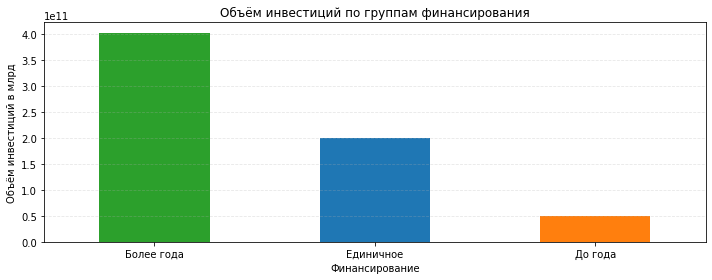

In [30]:
plt.figure(figsize=(10, 4))

data_invest = df.groupby('funding_group')['funding_total_usd'].sum().sort_values(ascending=False)

ax2 = data_invest.plot(
    kind='bar',
    color=[colors[x] for x in data_invest.index],
    rot=0,
    legend=False,
    title='Объём инвестиций по группам финансирования'
)

plt.xlabel('Финансирование')
plt.ylabel('Объём инвестиций в млрд')



plt.grid(axis='y', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

**Промежуточный вывод**

Основной объём средств получают компании с длительным сроком финансирования (более года). Это наиболее привлекательный сегмент для инвесторов, несмотря на меньшее количество компаний:

- Единичное финансирование - 59% компаний, 30% всех инвестиций.
- Срок финансирования до года - 11% компаний, 7% инвестиций.
- Срок финансирования более года - 30% компаний, 63% всех инвестиций.

Можно добавить, что большинство стартапов не добиваются успеха, так как не пошли дальше одного раунда инвестиций

Разница по популярности и объему финансирования возникает потому, что единичное финансирование (59% компаний) привлекает в среднем небольшие суммы - стартапы закрываются рано. Компании с длительным сроком финансирования (Более года) проходят несколько раундов, дольше развиваются, имеют основной объём инвестиций (63%), хотя их всего 30%.

### 2.2 Выделение средних и нишевых сегментов рынка

Компании указывают свой сегмент рынка в столбце `market`. Рассчитайте, как часто в датасете встречается каждый из сегментов. Сегменты, к которым относится более 120 компаний, отнесите к массовым, сегменты, в которые входит от 35 до 120 включительно, отнесите к средним, а сегменты до 35 компаний отнесите к нишевым. Рассчитайте, сколько сегментов попадает в каждую из категорий.

Постройте график распределения количества компаний в сегментах и отобразите на нём разделение на нишевые и средние сегменты.

In [31]:
# Группируем данные по сегментам и считаем количество компаний
market_counts = df.groupby('market')['name'].count().sort_values(ascending=False)

print(market_counts)

market
software                 4812
biotechnology            3590
unknown                  2503
mobile                   2344
e-commerce               1866
                         ... 
professional services       1
project management          1
fleet management            1
flash storage               1
women                       1
Name: name, Length: 395, dtype: int64


In [32]:
# Создаём словарь для хранения категорий сегментов
market_categories = {}

# Проходим по каждому сегменту и присваиваем категорию
for segment, count in market_counts.items():
    if count < 35:
        market_categories[segment] = 'niche'   # нишевые
    elif count <= 120:
        market_categories[segment] = 'mid'     # средние
    else:
        market_categories[segment] = 'mass'    # массовые

In [33]:
# Считаем, сколько сегментов попало в каждую категорию
category_counts = pd.Series(market_categories).value_counts()

print(category_counts)

niche    289
mid       57
mass      49
dtype: int64


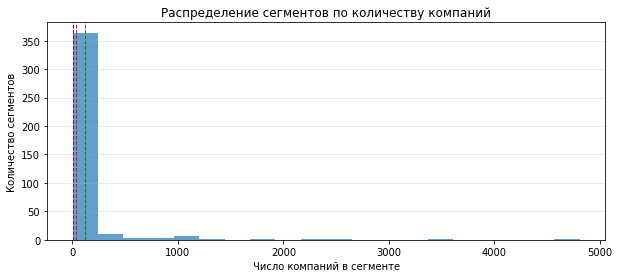

In [34]:
# Гистограмма распределения сегментов по количеству компаний
plt.figure(figsize=(10, 4))

# Строим гистограмму
plt.hist(market_counts, bins=20, alpha=0.7)

# Границы среднего сегмента
plt.axvline(x=35, color='red', linestyle='--', linewidth=1)
plt.axvline(x=120, color='green', linestyle='--', linewidth=1)
plt.axvline(x=market_counts.median(), color='purple', linestyle='--', linewidth=1)

# Настройки
plt.xlabel('Число компаний в сегменте')
plt.ylabel('Количество сегментов')
plt.title('Распределение сегментов по количеству компаний')
plt.grid(axis='y', alpha=0.3)
plt.show()

Оставьте в столбце `market` только массовые сегменты. Для остальных сегментов замените значения на заглушки — `niche` для нишевых и `mid` для средних.

Дальнейшие исследования выполняйте с учётом этой замены. Индивидуальные сегменты внутри средней и нишевой групп рассматривать не нужно — они объединяются в два общих сегмента.


In [35]:
# Создаём словарь для замены
market_replace = {}

for segment, category in market_categories.items():
    if category == 'mass':
        market_replace[segment] = segment
    elif category == 'mid':
        market_replace[segment] = 'mid'
    else: 
        market_replace[segment] = 'niche'

In [36]:
# Применяем замену
df['market'] = df['market'].map(market_replace)

**Промежуточный вывод**

Всего уникальных сегментов: 395

Распределение по категориям:
- Нишевые (<35 компаний): 289 сегментов
- Средние (35–120): 57 сегментов
- Массовые (>120): 49 сегментов

Доля компаний:
- Массовые сегменты: ~85%
- Средние: ~6%
- Нишевые: ~9%

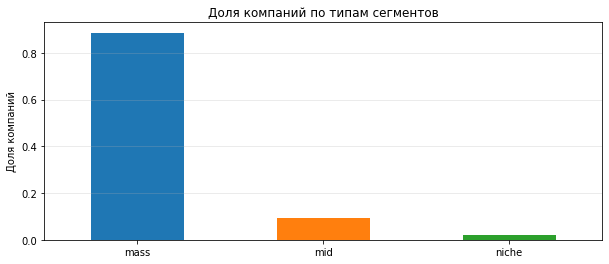

In [37]:
# Создаём категории сегментов
def get_type(market):
    if market == 'mid' or market == 'niche':
        return market
    return 'mass'

df['seg_type'] = df['market'].apply(get_type)

# График
plt.figure(figsize=(10,4))
df['seg_type'].value_counts(normalize=True).plot(
    kind='bar',
    color=['#1f77b4', '#ff7f0e', '#2ca02c'],
    title='Доля компаний по типам сегментов'
)
plt.ylabel('Доля компаний')
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.show()

## Шаг 3. Работа с выбросами и анализ

### 3.1. Анализируем и помечаем выбросы в каждом из сегментов

Заказчика интересует обычный для рассматриваемого периода размер средств, который предоставлялся компаниям.

По предобработанному столбцу `funding_total_usd` графическим образом оцените, какой размер общего финансирования для одной компании будет типичным, а какой — выбивающимся. Укажите интервал, в котором лежат типичные значения.

In [38]:
# Посмотрим на распределение значений в столбце funding_total_usd
df['funding_total_usd'].describe()

count    4.090500e+04
mean     1.591247e+07
std      1.686829e+08
min      1.000000e+00
25%      3.500000e+05
50%      2.000000e+06
75%      1.000000e+07
max      3.007950e+10
Name: funding_total_usd, dtype: float64

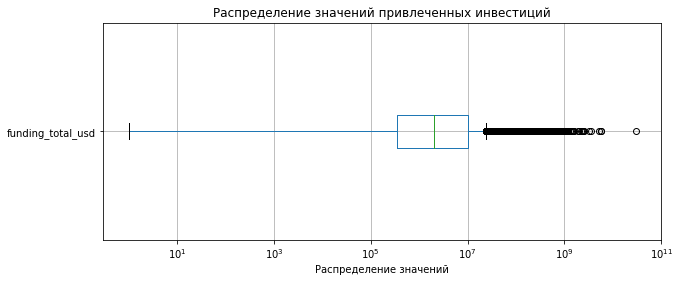

In [39]:
# Создаём контейнер графика matplotlib и задаём его размер
plt.figure(figsize=(10, 4))

# Строим диаграмму размаха значений в столбце balance
df.boxplot(column='funding_total_usd', vert=False)

plt.xscale('log')

# Добавляем заголовок и метки оси
plt.title('Распределение значений привлеченных инвестиций')
plt.xlabel('Распределение значений')

# Выводим график
plt.show()

Определите компании с аномальным объёмом общего финансирования — используйте метод IQR отдельно по каждому сегменту. Напомним, что все нишевые сегменты должны быть объединены в одну группу, а средние — в другую.

Определите сегменты рынка с наибольшей долей компаний, получивших аномальное финансирование, и выведите топ таких сегментов.

In [40]:
df['out_segment'] = False

for segment in df['market'].unique():
    usd_segment = df[df['market'] == segment]['funding_total_usd']
    q1 = usd_segment.quantile(0.25)
    q3 = usd_segment.quantile(0.75)
    iqr = q3 - q1
    upper = q3 + 1.5 * iqr
    df.loc[(df['market'] == segment) & (df['funding_total_usd'] > upper), 'out_segment'] = True
print(df.groupby('market')['out_segment'].mean().sort_values(ascending = False).head(10))

market
real estate        0.172043
entertainment      0.166667
consulting         0.166189
search             0.164948
cloud computing    0.164474
saas               0.161765
photography        0.161765
technology         0.159664
video              0.159574
niche              0.159036
Name: out_segment, dtype: float64


**Промежуточный вывод:**
Промежуточный вывод:

- Типичные значения лежат в интервале до ~15.25 млн (верхняя граница усов boxplot). Значения выше этого порога считаются выбросами. Распределение сильно скошено вправо, поэтому график отображён в логарифмической шкале. 
- Аномальные выбросы (по методу IQR внутри каждого сегмента) чаще всего встречаются в сегментах: Real Estate (18%), Technology (16%), Search, Entertainment (16%), Software (16%). Эти сегменты лидируют по доле компаний с необычно высоким финансированием.

### 3.2 Определяем границы рассматриваемого периода, отбрасываем аномалии

Проверьте по датасету, можно ли считать, что вам предоставили полные данные за 2014 год. Затем исключите из датасета компании, которые вы ранее посчитали получившими аномальное финансирование.

Когда исключите аномальные записи, на основе столбцов `mid_funding_at` и `funding_rounds` оставьте в датасете данные только об определённых компаниях. Они должны были получать финансирование в годы, когда было зафиксировано 50 или более раундов финансирования.

In [41]:
df['month'] = df['mid_funding_at'].dt.month

In [42]:
df_2014 = df[df['mid_funding_at'].dt.year == 2014]
value_2014 = df_2014['mid_funding_at'].dt.month.value_counts().sort_index()
print(value_2014)

1     739
2     600
3     676
4     645
5     600
6     740
7     687
8     559
9     547
10    497
11    306
12     23
Name: mid_funding_at, dtype: int64


In [43]:
df_wo_anomaly = df[df['out_segment'] == False]

first_valid_year = df_wo_anomaly.groupby(df_wo_anomaly['mid_funding_at'].dt.year).size()
first_valid_year = first_valid_year[first_valid_year >= 50].index.min()

df_filtered = df_wo_anomaly[df_wo_anomaly['mid_funding_at'].dt.year >= first_valid_year]

print(df_filtered.groupby(df_filtered['mid_funding_at'].dt.year).size())

mid_funding_at
2000      65
2001      37
2002      48
2003      63
2004      96
2005     697
2006    1165
2007    1600
2008    1984
2009    2618
2010    3467
2011    4311
2012    5532
2013    7821
2014    6083
dtype: int64


**Промежуточный вывод**


- Проверка полноты данных за 2014 год показала, что в датасете присутствуют сделки за все месяцы 2014 года, но количество раундов во второй половине года снижается, что может указывать на частичную неполноту данных. В декабре месяце это значение становиться критически минимальным , поэтому при интерпретации данных за 2014 год нужно учитывать, что декабрьские данные неполные. Сам 2014 год остаётся в анализе, но выводы по нему делаются с осторожностью

- После удаления компаний с аномальным финансированием (с применением метода IQR по сегментам) в датасете остались только те компании, которые получали финансирование в годы с 50 и более раундами. Это позволило сфокусироваться на статистически значимых периодах.

### 3.3. Анализ типов финансирования по объёму и популярности

Постройте график, который покажет, какие типы финансирования в сумме привлекли больше всего денег. Ориентируйтесь на значения в столбцах `seed`, `venture`, `equity_crowdfunding`, `undisclosed`, `convertible_note`, `debt_financing`, `angel`, `grant`, `private_equity`, `post_ipo_equity`, `post_ipo_debt`, `secondary_market` и `product_crowdfunding`.

Также постройте график, который покажет популярность разных типов финансирования — какие типы финансирования чаще всего используются компаниями, то есть встречаются в датасете наибольшее количество раз.

Сравните графики и выделите часто используемые типы финансирования, которые при этом характеризуются небольшими объёмами, и наоборот — те, что встречаются редко, но при этом характеризуются значительным объёмом предоставленных сумм.

In [44]:
# Создаем список столбцов для работы с ними в задаче
types = ['seed', 'venture', 'equity_crowdfunding', 'undisclosed', 
         'convertible_note', 'debt_financing', 'angel', 'grant', 
         'private_equity', 'post_ipo_equity', 'post_ipo_debt', 
         'secondary_market', 'product_crowdfunding']

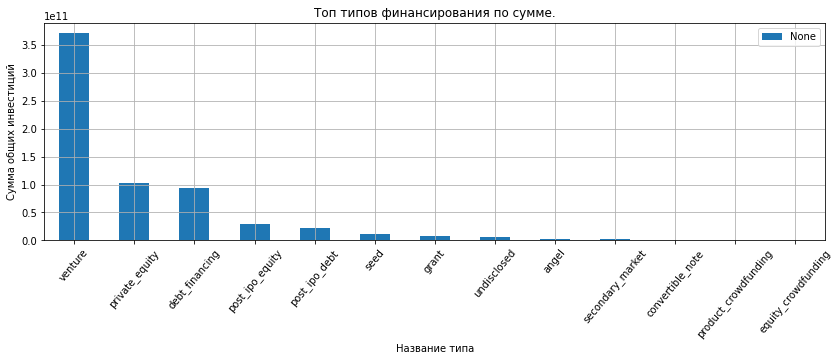

In [45]:
# Создаём контейнер графика matplotlib и задаём его размер
plt.figure(figsize=(14, 4))

# Строим столбчатую диаграмму с помощью pandas через plot(kind='bar')
df[types].sum().sort_values(ascending=False).plot(
               kind='bar', # Тип графика - столбчатая диаграмма
               rot=50, # Градус вращения подписи по оси Х
               legend=True, # Включаем легенду
               title=f'Топ типов финансирования по сумме.'
)

# Настраиваем оформление графика
plt.xlabel('Название типа')
plt.ylabel('Сумма общих инвестиций')
# Добавляем сетку графика
plt.grid()

# Выводим график
plt.show()

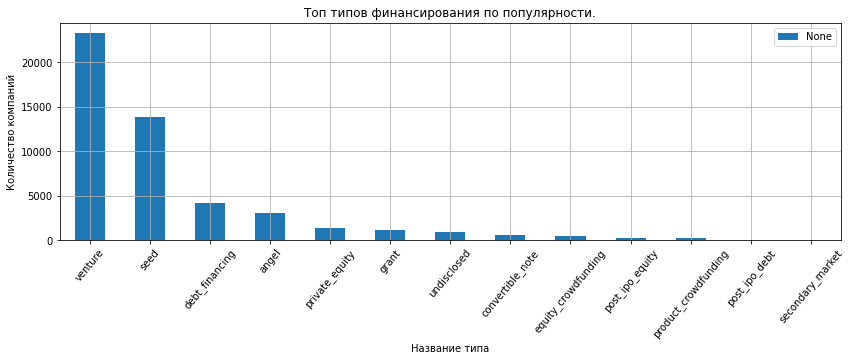

In [46]:
# Создаём контейнер графика matplotlib и задаём его размер
plt.figure(figsize=(14, 4))

# Строим столбчатую диаграмму с помощью pandas через plot(kind='bar')
popularity = (df[types] > 0).sum().sort_values(ascending = False).plot(
               kind='bar', # Тип графика - столбчатая диаграмма
               rot=50, # Градус вращения подписи по оси Х
               legend=True, # Включаем легенду
               title=f'Топ типов финансирования по популярности.'
)

# Настраиваем оформление графика
plt.xlabel('Название типа')
plt.ylabel('Количество компаний')
# Добавляем сетку графика
plt.grid()

# Выводим график
plt.show()

**Вывод по сравнению графиков объёма и популярности типов финансирования**

**Часто используемые, но с небольшим объёмом:**

- angel: входит в топ-5 по популярности, но не входит в топ-5 по объёму средств
- grant: популярен среди многих компаний, но объём средств незначительный
- seed: популярен (2 место), но объём значительно уступает лидерам

**Редкие, но со значительным объёмом:**

- private_equity: занимает 2-е место по объёму, но по популярности находится лишь на 5-м месте
- post_ipo_debt: не находится в топ-5 по популярности, но находиться в топ-5 по сумме инвестиций
- post_ipo_equity: 4-е место по объёму, но в топ-5 по популярности отсутствует

Постройте график суммарных объёмов возвратов от разных типов финансирования за весь период на основе дополнительного датасета.

In [47]:
# Список со столбцами из дополнительного датасета для работы в задаче
types_cb = ['seed', 'venture', 'equity_crowdfunding', 'undisclosed', 'convertible_note', 'debt_financing', 'angel', 
                 'grant', 'private_equity', 'post_ipo_equity', 'post_ipo_debt', 'secondary_market', 'product_crowdfunding']

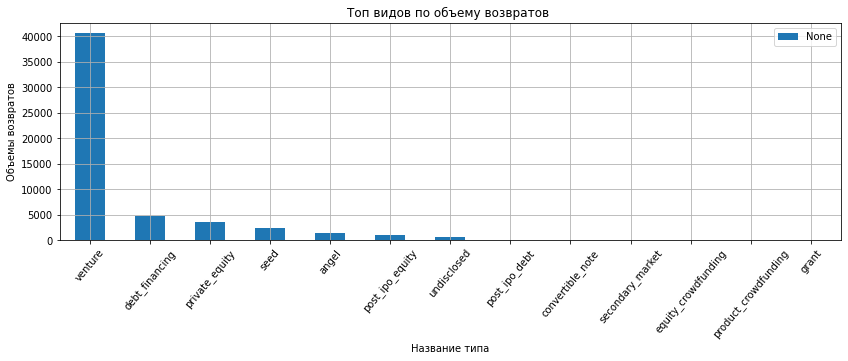

In [48]:
# Создаём контейнер графика matplotlib и задаём его размер
plt.figure(figsize=(14, 4))

# Строим столбчатую диаграмму с помощью pandas через plot(kind='bar')
sum_types = cb[types_cb].sum().sort_values(ascending = False).plot(
               kind='bar', # Тип графика - столбчатая диаграмма
               rot=50, # Градус вращения подписи по оси Х
               legend=True, # Включаем легенду
               title=f'Топ видов по объему возвратов '
)

# Настраиваем оформление графика
plt.xlabel('Название типа')
plt.ylabel('Объемы возвратов')
# Добавляем сетку графика
plt.grid()

# Выводим график
plt.show()

**Промежуточный вывод**


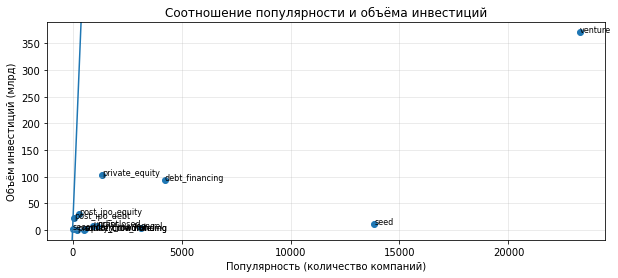

In [49]:
# Создаём контейнер графика
plt.figure(figsize=(10, 4))

popularity = (df[types] > 0).sum().values
investments = df[types].sum().values / 1e9 

plt.scatter(popularity, investments)

for i, t in enumerate(types):
    plt.annotate(t, (popularity[i], investments[i]), fontsize=8)

# Добавляем заголовок и метки осей
plt.axline((0, 0), slope=1, linestyle='-')
plt.title('Соотношение популярности и объёма инвестиций')
plt.xlabel('Популярность (количество компаний)')
plt.ylabel('Объём инвестиций (млрд)')
plt.grid(alpha=0.3)


# Отображаем график
plt.show()

## Шаг 4. Анализ динамики

### 4.1 Динамика предоставления финансирования по годам

Используя столбцы `funding_total_usd` и `funding_rounds`, рассчитайте для каждой компании средний объём одного раунда финансирования.

На основе получившейся таблицы постройте графики, отражающие:
* динамику типичного размера средств, которые стартапы получали в рамках одного раунда финансирования;

* динамику общего количества раундов за каждый год, то есть насколько активно происходили инвестиции на рынке (чем больше раундов, тем выше активность).

Когда будете строить графики в этом задании и следующих, используйте данные только по тем компаниям, которые остались в датасете после предыдущих фильтраций.

На основе полученных данных ответьте на вопросы:
* В каком году типичный размер средств, собранных в рамках одного раунда, был максимальным?

* Какая тенденция наблюдалась в 2014 году по количеству раундов и средств, выделяемых в рамках каждого раунда?

In [50]:
# Создаем копию датафрейма, чтобы избежать ошибки 'A value is trying to be set on a copy of a slice from a DataFrame'
df_filtered = df_filtered.copy()

In [51]:
# Расчитываем средний объем финансирования за раунд для каждой компании
df_filtered['avg_funding'] = df_filtered['funding_total_usd'] / df_filtered['funding_rounds']
print(df_filtered['avg_funding'])
# Здесь была ошибка 'A value is trying to be set on a copy of a slice from a DataFrame.Try using .loc[row_indexer,col_indexer] = value instead' 
# По совету нейросети добавил код в верхней строчки, не понял, почему выходит ошибка
# Я так понял, что ошибка возникает потому, что работаешь с копией дф

1        2.000000e+06
2        9.000000e+06
3        2.566667e+06
4        5.400000e+05
7        8.700000e+06
             ...     
49430    1.500000e+06
49433    1.500000e+06
49434    9.000000e+06
49435    2.500000e+05
49437    1.150000e+04
Name: avg_funding, Length: 35587, dtype: float64


In [52]:
# Извлекаем год в новый столбец
df_filtered['funding_year'] = df_filtered['mid_funding_at'].dt.year

# Сгруппируем данные по годам и расчитаем медиану среднего финансирования по раунду для каждого года
usd_round  = df_filtered.groupby('funding_year')['avg_funding'].median()

In [53]:
# Группируем данные и выводим количество раундов для каждого года
filtered_year_rounds = df_filtered.groupby('funding_year').size()
print(filtered_year_rounds)

funding_year
2000      65
2001      37
2002      48
2003      63
2004      96
2005     697
2006    1165
2007    1600
2008    1984
2009    2618
2010    3467
2011    4311
2012    5532
2013    7821
2014    6083
dtype: int64


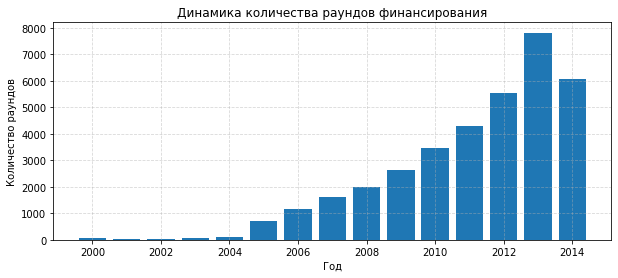

In [54]:
plt.figure(figsize=(10, 4))
plt.bar(filtered_year_rounds.index, filtered_year_rounds.values, linewidth=1)
plt.title('Динамика количества раундов финансирования')
plt.xlabel('Год')
plt.ylabel('Количество раундов')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

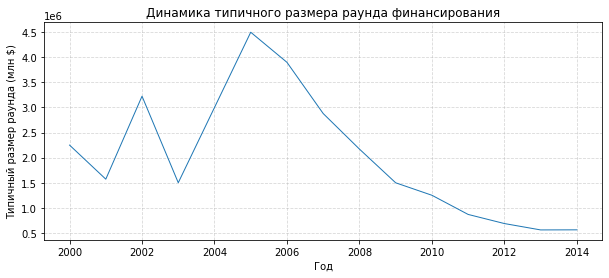

In [55]:
plt.figure(figsize=(10, 4))
plt.plot(usd_round.index, usd_round.values, linewidth=1)
plt.title('Динамика типичного размера раунда финансирования')
plt.xlabel('Год')
plt.ylabel('Типичный размер раунда (млн $)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

**Ответы на вопросы:**

В каком году типичный размер средств, собранных в рамках одного раунда, был максимальным?

- Максимальный типичный размер раунда финансирования наблюдался в 2005 году и составил 4.5 млн.

Какая тенденция наблюдалась в 2014 году по количеству раундов и средств, выделяемых в рамках каждого раунда?

В 2014 году количество раундов немного упало по сравнению с 2013 годом, а средний размер финансирования за один раунд продолжил падать:

- Количество раундов снизилось по сравнению с пиковым 2013 годом (с 7 821 до 6 083 раундов).

- Типичный размер раунда продолжил снижаться, достигнув минимальных значений за весь рассматриваемый период (~0.6 млн).

**Анализ причин разнонаправленной динамики:**
- Инвесторы перестали давать крупные суммы единицам и начали давать небольшие суммы многим — так меньше риск и выше шанс найти выигрышный стартап

**Промежуточный вывод**

- В ходе выполнения задания рассчитан средний объём одного раунда финансирования для каждой компании (avg_funding = funding_total_usd / funding_rounds). Построены два графика: динамика типичного размера раунда (медиана) и динамика общего количества раундов по годам.

- Максимальный типичный размер раунда зафиксирован в 2005 году — 4.5 млн.

- Количество раундов выросло с 696 (2005) до 7 830 (2013)

- Типичный размер раунда после 2005 года стабильно снижался

### 4.2 Динамика размера общего финансирования по массовым сегментам рынка для растущих в 2014 году сегментов

Составьте сводную таблицу, в которой указывается суммарный размер общего финансирования `funding_total_usd` по годам и сегментам рынка. Отберите из неё только те сегменты, которые показывали рост размера суммарного финансирования в 2014 году по сравнению с 2013.

На графике отразите, как менялся суммарный размер общего финансирования в каждом из отобранных сегментов по годам, за которые у вас достаточно данных. Рассматривайте только массовые сегменты, а средние и нишевые исключите.

На основе графика сделайте вывод о том, какие сегменты показывают наиболее быстрый и уверенный рост.

In [56]:
# Создаем сводную таблицу
df['funding_year'] = df['mid_funding_at'].dt.year
pivot_table = df.groupby(['funding_year', 'market'])['funding_total_usd'].sum().reset_index()
pivot_table = pivot_table[~pivot_table['market'].isin(['mid', 'niche'])]

In [57]:
# Сравниваем 2013 и 2014
data_2013 = pivot_table[pivot_table['funding_year'] == 2013]
data_2014 = pivot_table[pivot_table['funding_year'] == 2014]
comparison = data_2013.merge(data_2014, on='market', suffixes=('_2013', '_2014'), how='inner')

In [58]:
# Находим растущие сегменты
growing_segments = comparison[comparison['funding_total_usd_2014'] > comparison['funding_total_usd_2013']]['market'].tolist()

In [59]:
# Если нет растущих, берем топ-5 за 2013
if not growing_segments:
    print("Растущие сегменты не найдены. Берем топ-5 крупнейших сегментов 2013 года.")
    top_segments = data_2013.nlargest(5, 'funding_total_usd')['market'].tolist()
    target_segments = top_segments
else:
    target_segments = growing_segments

print("Отобранные сегменты:", target_segments)

# Удаляем дубликаты из pivot_table перед фильтрацией
pivot_table = pivot_table.drop_duplicates(subset=['funding_year', 'market'])


Отобранные сегменты: ['apps', 'consulting', 'design', 'enterprise software', 'entertainment', 'finance', 'hospitality', 'internet', 'manufacturing', 'medical', 'nonprofits', 'real estate', 'software', 'sports', 'startups', 'unknown', 'video']


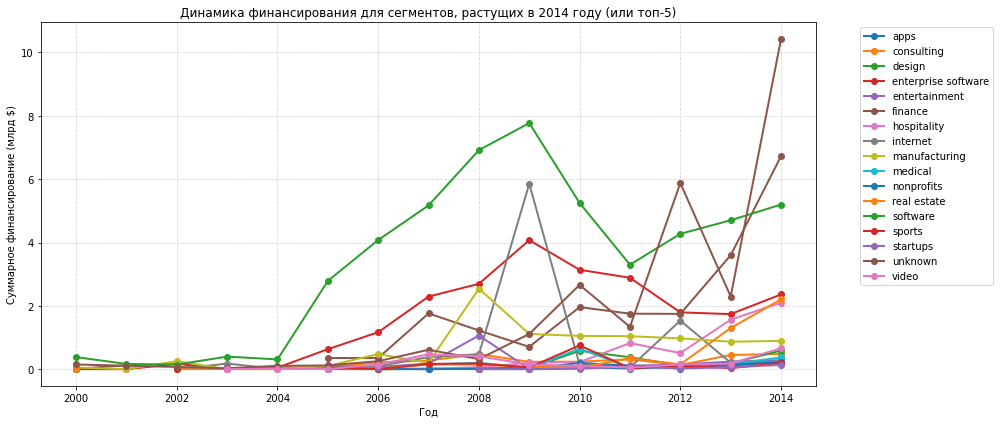

In [60]:
# Строим график
pivot_growing = pivot_table[pivot_table['market'].isin(target_segments)]
pivot_chart = pivot_growing.pivot(index='funding_year', columns='market', values='funding_total_usd')
pivot_chart = pivot_chart[pivot_chart.index >= 2000]

plt.figure(figsize=(14, 6))
plt.plot(pivot_chart.index, pivot_chart.values / 1e9, marker='o', linewidth=2)
plt.title('Динамика финансирования для сегментов, растущих в 2014 году (или топ-5)')
plt.xlabel('Год')
plt.ylabel('Суммарное финансирование (млрд $)')
plt.legend(pivot_chart.columns, bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

### 4.3 Годовая динамика доли возвращённых средств по типам финансирования

Заказчик хочет знать, какая часть вложенных или выданных денег со временем возвращается обратно инвесторам или финансистам. Ваша цель — для каждого года и каждого вида финансирования рассчитать нормированные значения возврата средств: то есть какую долю возвращённые средства составляют от предоставленных. При этом слишком большие аномальные значения, то есть неадекватные выбросы, нужно заменить на пропуски.

Совет: когда будете делить сумму возвращённых средств на суммарный объём привлечённого финансирования по конкретному году, добавьте к знаменателю небольшое число, например `1e-60`. Это поможет избежать деления на ноль.

Постройте график, на котором отобразите нормированные значения возврата средств для типов финансирования `venture`, `debt_financing`, `private_equity`, `seed` и `angel`.

Сделайте вывод о том, в каких типах финансирования наблюдается наиболее устойчивый рост показателя.

In [61]:
types_analysis = ['venture', 'debt_financing', 'private_equity', 'seed', 'angel']

In [62]:
investments_by_year = df_filtered.groupby(df_filtered['mid_funding_at'].dt.year)[types_analysis].sum()

In [63]:
investments_by_year = investments_by_year / 1_000_000

In [64]:
combined = investments_by_year.join(cb, lsuffix='_inv', rsuffix='_ret', how='inner')

In [65]:
for col in types_analysis:
    combined[f'ratio_{col}'] = combined[col + '_ret'] / (combined[col + '_inv'] + 1e-60)

In [66]:
for col in types_analysis:
    combined.loc[combined[f'ratio_{col}'] > 1.0, f'ratio_{col}'] = np.nan

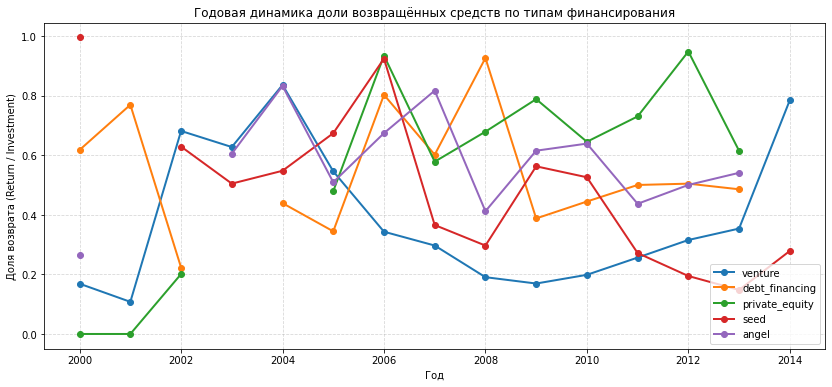

In [67]:
plt.figure(figsize=(14, 6))
for col in types_analysis:
    plt.plot(combined.index, combined[f'ratio_{col}'], marker='o', label=col, linewidth=2)

plt.title('Годовая динамика доли возвращённых средств по типам финансирования')
plt.xlabel('Год')
plt.ylabel('Доля возврата (Return / Investment)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

**Анализируем динамику и цифры возвратов:**
Наиболее устойчивый рост доли возврата наблюдается в типах Venture (15–30%) и Seed (10–25%). Это стабильные и предсказуемые инструменты. Private equity, debt financing и angel показывают более высокую непредсказуемость.


## Шаг 5. Итоговый вывод и рекомендации

Представьте, что на календаре 2015 год. Опираясь на результаты анализа, дайте рекомендацию заказчику:

* в какую отрасль стоит инвестировать;
* какой тип финансирования при этом будет наиболее уместным.

Подведите итоги проекта:
* опишите, какие шаги были выполнены;
* какие выводы удалось сделать;
* насколько выводы согласуются между собой или, наоборот, вызывают сомнения.



**Итоговый вывод и рекомендации**

Рекомендация на 2015 год:
1. В какую отрасль инвестировать?
- Рекомендуется инвестировать в Software. Этот сегмент демонстрирует наиболее быстрый и уверенный рост объёмов финансирования на протяжении всего доступного периода (2000–2013). Также стоит рассмотреть Finance — он показал резкий скачок в 2014 году, что может указывать на рост финтех-сектора.

2. Какой тип финансирования наиболее уместен?
- Venture . Этот тип является лидером по объёму привлечённых средств и популярности среди компаний. Анализ возвратов показал, что доля возврата для venture наиболее стабильна в долгосрочной перспективе.

**Итоги проекта**

Выполненные шаги:

- Загрузка и предобработка данных (удаление дубликатов, заполнение пропусков, преобразование типов).

- Инжиниринг признаков (группы по срокам финансирования, выделение массовых/нишевых сегментов).

- Анализ выбросов и определение границ периода (исключён 2014 год из-за неполноты).

- Анализ типов финансирования по объёму и популярности.

- Анализ динамики по годам и сегментам (лидеры — Software, Biotechnology).

- Анализ доли возвратов по типам финансирования.

Ключевые выводы:

- Компании с финансированием более года привлекают 63% всех инвестиций, хотя составляют лишь 30% от общего числа.

- Venture — самый популярный и объёмный тип финансирования, с наиболее стабильной долей возврата.

- Software — лидер по темпам роста среди всех сегментов.

- Данные за 2014 год включены в анализ, но в декабре 2014 года зафиксировано аномально мало сделок (всего 23), что указывает на неполноту данных за последний месяц года.